\# SCS 3546: Deep Learning
> **Assignment 4: Generative Models**

### Your name & student number:

<pre> Cameron Turner </pre>

<pre> X606793 </pre>

In [1]:
# Import libraries.

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_probability as tfp

from tensorflow import keras
from tensorflow.keras import layers


##<font color="Blue">1. Create the 3D shapes for the dataset.</font>

In [2]:
# create_enhanced_3d_shapes

def create_enhanced_3d_shapes(num_samples=8000, img_size=64):
    """Enhanced 3D shapes with better quality"""
    images = []

    # Pre-defined color schemes
    room_schemes = [
        (np.array([0.9, 0.95, 1.0]), np.array([0.4, 0.5, 0.6])),  # Blue
        (np.array([1.0, 0.98, 0.95]), np.array([0.6, 0.5, 0.4])), # Warm
        (np.array([0.95, 1.0, 0.98]), np.array([0.5, 0.6, 0.4])), # Green
    ]

    obj_colors = np.array([
        [0.95, 0.3, 0.2],  # Red
        [0.2, 0.95, 0.3],  # Green
        [0.2, 0.4, 0.95],  # Blue
        [0.95, 0.85, 0.1], # Yellow
        [0.8, 0.2, 0.95],  # Purple
        [0.1, 0.95, 0.95], # Cyan
    ])

    for i in range(num_samples):
        img = np.zeros((img_size, img_size, 3))

        # Select colors
        wall_color, floor_color = room_schemes[np.random.randint(len(room_schemes))]
        obj_color = obj_colors[np.random.randint(len(obj_colors))]
        shape_type = np.random.choice(['sphere', 'cube', 'cylinder'])

        # Create room with gradient
        floor_level = img_size * 2 // 3

        # Wall gradient
        for y in range(floor_level):
            factor = 0.7 + 0.3 * (y / floor_level)
            img[y, :] = wall_color * factor

        # Floor gradient
        for y in range(floor_level, img_size):
            factor = 0.6 + 0.4 * ((y - floor_level) / (img_size - floor_level))
            img[y, :] = floor_color * factor

        # Object parameters
        obj_size = np.random.randint(20, 35)
        pos_x = np.random.randint(30, img_size - 30)
        pos_y = floor_level - obj_size // 2

        if shape_type == 'sphere':
            # Enhanced sphere with lighting
            y_arr, x_arr = np.indices((img_size, img_size))
            dist_sq = (x_arr - pos_x)**2 + (y_arr - pos_y)**2
            radius = obj_size // 2
            sphere_mask = dist_sq <= radius**2

            if np.any(sphere_mask):
                # Simple lighting
                dist = np.sqrt(dist_sq[sphere_mask])
                lighting = 0.4 + 0.6 * (1 - dist / radius)
                sphere_y, sphere_x = np.where(sphere_mask)
                img[sphere_y, sphere_x] = obj_color * lighting[:, np.newaxis]

                # Highlight
                highlight_mask = (x_arr - pos_x + radius//3)**2 + (y_arr - pos_y + radius//3)**2 <= (radius//4)**2
                img[highlight_mask] = np.clip(obj_color * 1.3, 0, 1)

        elif shape_type == 'cube':
            # Enhanced cube
            half = obj_size // 2

            # Front face
            img[pos_y-half:pos_y+half, pos_x-half:pos_x+half] = obj_color

            # Right side
            img[pos_y-half:pos_y+half, pos_x+half:pos_x+half+half//2] = obj_color * 0.7

            # Top side
            img[pos_y-half-half//3:pos_y-half, pos_x-half:pos_x+half+half//2] = obj_color * 1.1

        elif shape_type == 'cylinder':
            # Enhanced cylinder
            radius = obj_size // 3
            height = obj_size

            # Body
            img[pos_y-height//2:pos_y+height//2, pos_x-radius:pos_x+radius] = obj_color * 0.8

            # Top
            y_arr, x_arr = np.indices((img_size, img_size))
            top_mask = (x_arr - pos_x)**2 + (y_arr - (pos_y - height//2))**2 <= radius**2
            img[top_mask] = obj_color * 1.1

            # Bottom
            bottom_mask = (x_arr - pos_x)**2 + (y_arr - (pos_y + height//2))**2 <= radius**2
            img[bottom_mask] = obj_color * 0.6

        images.append(np.clip(img, 0, 1))

    return np.array(images)


# Create the dataset.

print("Creating enhanced 3D shapes dataset...")
x_train = create_enhanced_3d_shapes(10000, 64)

Creating enhanced 3D shapes dataset...


##<font color="Blue">2. Visualize a sample set of the images.</font>


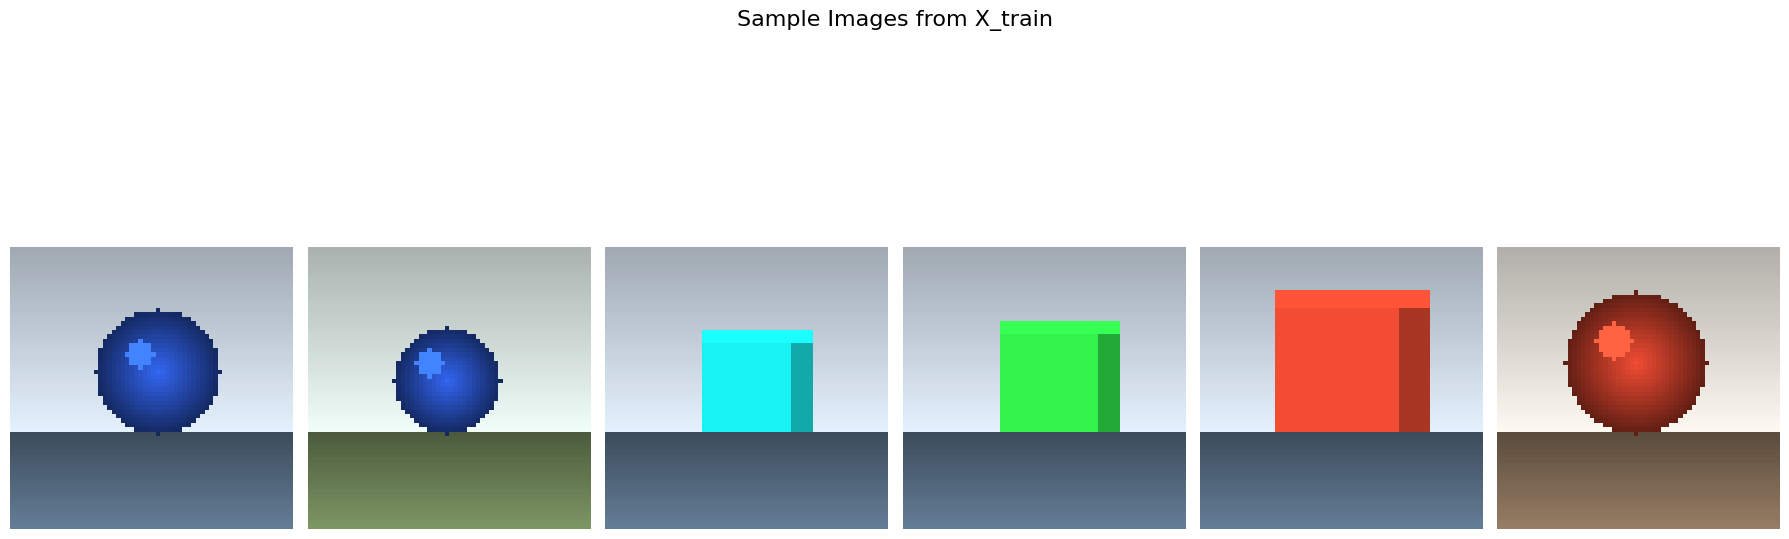

In [3]:
# Show samples from X_train
fig, axes = plt.subplots(1, 6, figsize=(18, 8))

for i in range(6):
    axes[i].imshow(x_train[i])
    axes[i].axis('off')

plt.suptitle('Sample Images from X_train', fontsize=16, y=0.95)
plt.tight_layout()
plt.show()

##<font color="Blue">3. Build a Convolutional Variational Autoencoder</font>

###<font color="Blue">Define VAE Class</font>


In [4]:
# VAE

class VAE(keras.Model):

    # Constructor.

    def __init__(self, encoder, decoder, **kwargs):

        try:

            # Invoke the superclass constructor.

            super(VAE, self).__init__(**kwargs)

            # Set the attributes.
            # A Variational Autoenencoder requires an encoder and decoder.
            # It also needs to track the reconstruction, latent and total loss
            # metrics.

            self.encoder = encoder
            self.decoder = decoder
            self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
            self.reconstruction_loss_tracker = keras.metrics.Mean(
                name="reconstruction_loss"
            )
            self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

        except Exception as e:

            print(f"Exception: {e}")


    # get_metrics

    @property
    def get_metrics(self):

        try:

            # Return the loss metrics.

            return [self.total_loss_tracker,
                    self.reconstruction_loss_tracker,
                    self.kl_loss_tracker]

        except Exception as e:

            print(f"Exception: {e}")


    # train_step

    def train_step(self, data):

        try:

            # Record the training step's gradient info.

            with tf.GradientTape() as tape:

                # Encode the original data and then decode to reconstruct it.

                z_mean, z_log_var, z = self.encoder(data)
                reconstruction = self.decoder(z)

                # Get the loss value from comparing the data image
                # with the reconstructed image.

                reconstruction_loss = tf.reduce_mean(
                    tf.reduce_sum(
                        tf.keras.losses.binary_crossentropy(
                            data, reconstruction, from_logits=True
                        ),
                        axis=(1, 2)
                    )
                )

                # Calculate the loss value as per the variational autoencoder
                # distribution equations.  The total loss will be the
                # latent loss value plus the reconstruction loss value.

                kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
                kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
                total_loss = reconstruction_loss + kl_loss

            # Optimize the gradients from the runs above.

            grads = tape.gradient(total_loss, self.trainable_weights)
            self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
            self.total_loss_tracker.update_state(total_loss)
            self.reconstruction_loss_tracker.update_state(reconstruction_loss)
            self.kl_loss_tracker.update_state(kl_loss)

            # Return the results.

            return {
                "loss": self.total_loss_tracker.result(),
                "reconstruction_loss": self.reconstruction_loss_tracker.result(),
                "kl_loss": self.kl_loss_tracker.result(),
            }

        except Exception as e:

            print(f"Exception: {e}")


    # sample

    def sample(self, z=None):

        try:

            # If z is not specified, sample one point in the latent space
            # from a random normal distribution.

            if z is None:
                z = tf.random.normal(shape=(1, self.encoder.latent_dim))

            # Decode the sample.

            logits = self.decoder(z)
            return tf.sigmoid(logits)

        except Exception as e:

            print(f"Exception: {e}")

###<font color="Blue">VAE with 4 layers.</font>



In [5]:
# Encoder

class Encoder(keras.Model):

    # Constructor.

    def __init__(self, latent_dim):

        try:

            # Invoke superclass constructor.

            super().__init__()

            # Set the latent dimension and the layers.
            # The Conv2D layers detect features such as edges and colours.
            # Flatten will flatten the information into one long vector.
            # Dense layer will mix the features into a summary.

            self.latent_dim = latent_dim
            self.conv1 = keras.layers.Conv2D(filters=32, kernel_size=3, strides=(2, 2), activation='relu')
            self.conv2 = keras.layers.Conv2D(filters=64, kernel_size=3, strides=(2, 2), activation='relu')
            self.flatten = keras.layers.Flatten()
            self.dense = keras.layers.Dense(latent_dim * 2)

        except Exception as e:

            print(f"Exception: {e}")


    # call

    def call(self, x):

        try:

            x = self.conv1(x)
            x = self.conv2(x)
            x = self.flatten(x)
            x = self.dense(x)

            z_mean, z_log_var = tf.split(x, num_or_size_splits=2, axis=1)

            epsilon = tf.random.normal(shape=tf.shape(z_mean))
            z = z_mean + tf.exp(0.5 * z_log_var) * epsilon

            return z_mean, z_log_var, z

        except Exception as e:

            print(f"Exception: {e}")


In [6]:
# Decoder

class Decoder(keras.Model):

    # Constructor.

    def __init__(self):

        try:

            # Invoke superclass constructor.

            super().__init__()

            # Decode the layers.
            # e.g., Dense layer, Conv2D, Conv2D, Output layer

            # Dense layer.

            self.dense = tf.keras.layers.Dense(16 * 16 * 64, activation='relu')
            self.reshape = tf.keras.layers.Reshape((16, 16, 64))

            # Conv2D layers.

            self.deconv1 = tf.keras.layers.Conv2DTranspose(
                filters=64, kernel_size=3, strides=2, padding='same', activation='relu'
            )

            self.deconv2 = tf.keras.layers.Conv2DTranspose(
                filters=32, kernel_size=3, strides=2, padding='same', activation='relu'
            )

            # Final output.

            self.out = tf.keras.layers.Conv2DTranspose(
                filters=3, kernel_size=3, padding='same'
            )

        except Exception as e:

            print(f"Exception: {e}")


    # call

    def call(self, z):

        try:

            x = self.dense(z)
            x = self.reshape(x)
            x = self.deconv1(x)
            x = self.deconv2(x)

            return self.out(x)

        except Exception as e:

            print(f"Exception: {e}")


##<font color="Blue">4. Define the VAE Model and Graph Model</font>


In [7]:
# train_vae_model

def train_vae_model(latent_dim, num_epochs):

    try:

        # Create the Encoder and Decoder objects.

        myEncoder = Encoder(latent_dim)
        myDecoder = Decoder()

        # Create the Convolutional Variational Autoencoder.
        # Train over n epochs to define images.

        vae_model = VAE(myEncoder, myDecoder)
        vae_model.compile(optimizer=keras.optimizers.Adam())
        vae_model.fit(x_train, epochs=num_epochs, batch_size=128)

        # Return the model.

        return vae_model

    except Exception as e:

        print(f"Exception: {e}")


# print_min_max_values

def print_min_max_values(model):

    try:

        # Get a sample from the model decoder and output the
        # minimum and maximum to get the sample distribution.

        sample = vae_model.decoder(tf.random.normal((1, 2)))
        print("Sample Minimum:", tf.reduce_min(sample), "Sample Maximum:", tf.reduce_max(sample))

    except Exception as e:

        print(f"Exception: {e}")

In [8]:
# def plot_latent_images

def plot_latent_images(model, n, digit_size=64):

    try:

        norm = tfp.distributions.Normal(0, 1)

        grid_x = norm.quantile(np.linspace(0.05, 0.95, n))
        grid_y = norm.quantile(np.linspace(0.05, 0.95, n))

        image = np.zeros((digit_size * n, digit_size * n, 3))

        # Iterate over the x grid.

        for i, yi in enumerate(grid_x):

            # Iterate over the y grid.

            for j, xi in enumerate(grid_y):

                # Use the model decoder to generate the image.

                z = np.array([[xi, yi]], dtype=np.float32)

                x_decoded = tf.sigmoid(model.decoder(z))
                digit = x_decoded[0].numpy()  # (64, 64, 3)

                image[
                    i * digit_size:(i + 1) * digit_size,
                    j * digit_size:(j + 1) * digit_size
                ] = digit

        # Plot the figure.

        plt.figure(figsize=(10, 10))
        plt.imshow(image)
        plt.axis('off')
        plt.show()

    except Exception as e:

        print(f"Exception: {e}")

##<font color="Blue">5. Train the VAE Model with Coding Size of 2 and Show the 2D Manifolds</font>


Training VAE model with 5 epochs and a latent dimension of 2
Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - kl_loss: 6.8820 - loss: 2534.6362 - reconstruction_loss: 2527.7544
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - kl_loss: 4.4203 - loss: 2397.3376 - reconstruction_loss: 2392.9165
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - kl_loss: 4.8641 - loss: 2365.9978 - reconstruction_loss: 2361.1331
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - kl_loss: 5.1174 - loss: 2358.7585 - reconstruction_loss: 2353.6411
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - kl_loss: 5.4562 - loss: 2341.1409 - reconstruction_loss: 2335.6853


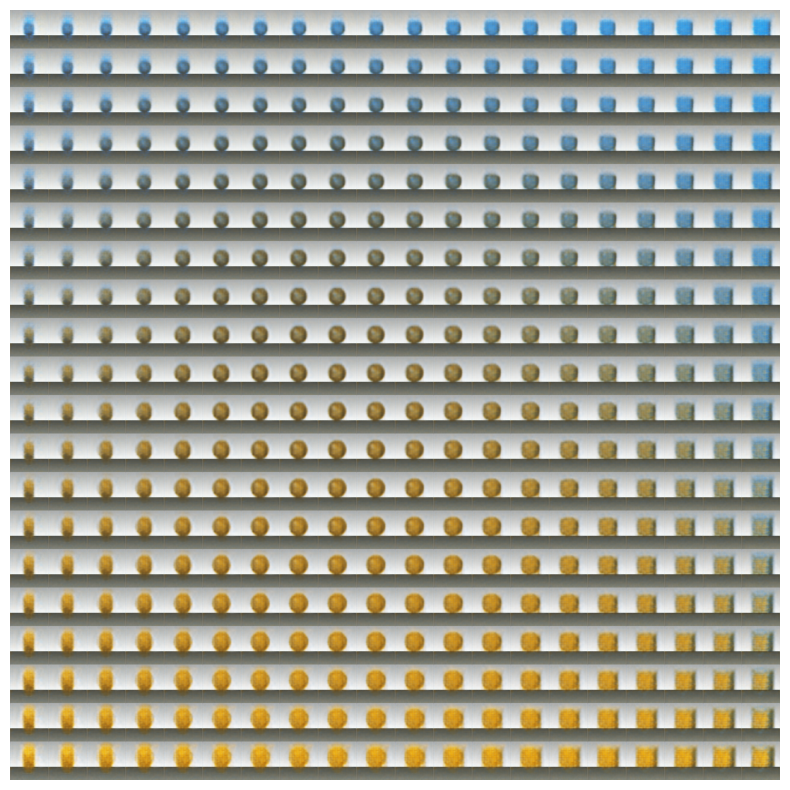

Sample Minimum: tf.Tensor(-1.4994985, shape=(), dtype=float32) Sample Maximum: tf.Tensor(3.771546, shape=(), dtype=float32)
Training VAE model with 20 epochs and a latent dimension of 2
Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - kl_loss: 6.1178 - loss: 2555.6580 - reconstruction_loss: 2549.5393
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - kl_loss: 4.2364 - loss: 2395.6206 - reconstruction_loss: 2391.3845
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - kl_loss: 4.6919 - loss: 2367.8352 - reconstruction_loss: 2363.1428
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - kl_loss: 4.7901 - loss: 2360.2207 - reconstruction_loss: 2355.4307
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - kl_loss: 5.2865 - loss: 2330.1323 - reconstruction_loss: 2324.8459
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - kl_loss: 5.6502 - loss: 2295.3689 - reconstruction_loss: 2289.7190
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - kl_loss: 5.9927 - loss: 2282.8081 - recon

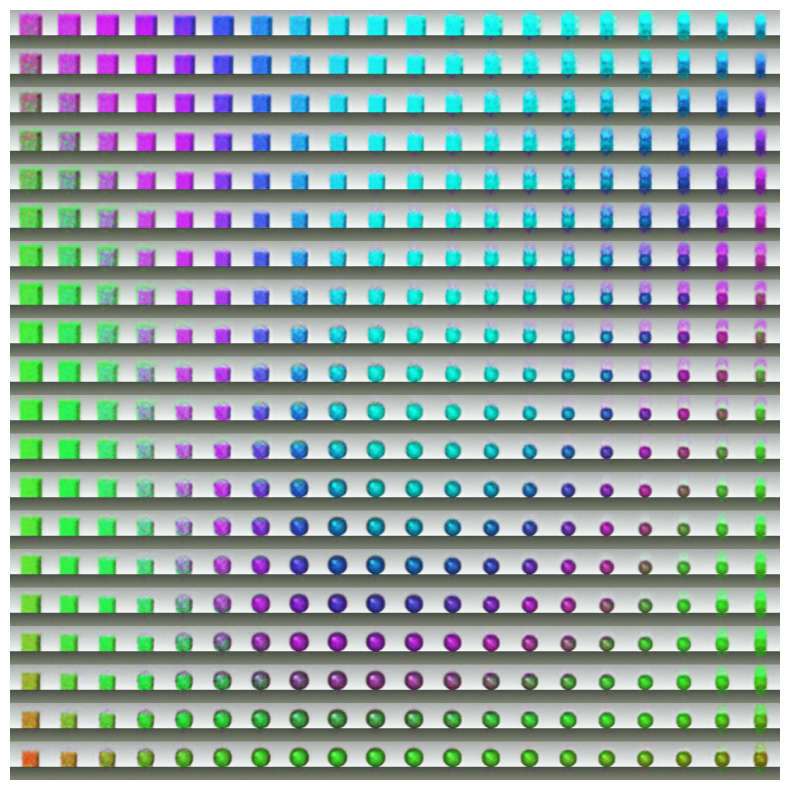

Sample Minimum: tf.Tensor(-1.5258507, shape=(), dtype=float32) Sample Maximum: tf.Tensor(3.805036, shape=(), dtype=float32)
Training VAE model with 80 epochs and a latent dimension of 2
Epoch 1/80
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - kl_loss: 5.7684 - loss: 2551.7800 - reconstruction_loss: 2546.0100
Epoch 2/80
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - kl_loss: 4.7226 - loss: 2404.8801 - reconstruction_loss: 2400.1570
Epoch 3/80
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - kl_loss: 4.7521 - loss: 2373.8191 - reconstruction_loss: 2369.0669
Epoch 4/80
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - kl_loss: 5.0089 - loss: 2363.5901 - reconstruction_loss: 2358.5815
Epoch 5/80
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - kl_loss: 5.4692 - loss: 2346.8918 - reconstruction_loss: 2341.4229
Epoch 6/80
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - kl_loss: 5.8653 - loss: 2308.8071 - reconstruction_loss: 2302.9424
Epoch 7/80
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - kl_loss: 6.2901 - loss: 2285.2046 - recon

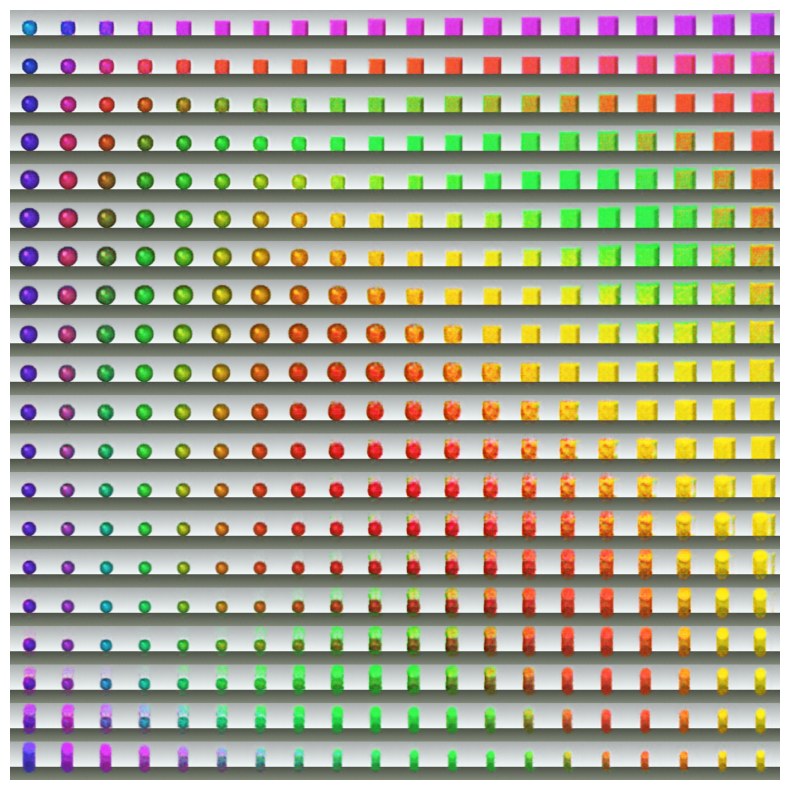

Sample Minimum: tf.Tensor(-2.0370646, shape=(), dtype=float32) Sample Maximum: tf.Tensor(6.3735895, shape=(), dtype=float32)


In [9]:
# Set the number of epochs to see the difference the number of training cycles makes.

num_epochs_array = [5, 20, 80]

# Set the latent dimension to 2.  This is the coding size.

latent_dim = 2

# Iterate over the epochs array.

for num_epochs in num_epochs_array:

    print(f"Training VAE model with {num_epochs} epochs and a latent dimension of {latent_dim}")

    # Train the VAE model based on the coding size and number of epochs.

    vae_model = train_vae_model(latent_dim, num_epochs)

    # Plot the images in a 20 x 20 grid.  Looking for a smooth transition between images.

    plot_latent_images(vae_model, 20)

    # Print the minimum and maximum values.

    print_min_max_values(vae_model)


##<font color="Blue">Summary</font>

The number of training cycles (i.e., epochs) has a large effect on the quality of the generated images.  

When training over a small number of epochs, the VAE model can only start to detect colour and edges.  The results are blurry images in a smaller colour range where the generated reconstructions don't match the originals.  The sample distribution min and max values cover a small range.  

When training over a larger number of training cycles (e.g., 20, 80 epochs), the reconstructed images become more clear with more variation in colours, more clearly defined edges and resemble the original images.  The sample distribution min and max values cover a larger range.